## IRT(Item Response Theory)によるテスト結果評価
+ $\alpha_{j}$ 識別力 (問題)
+ $b_{j}$ 困難度 (問題)
+ $\\theta_{i}$ 能力値(受験者)
  
2パラメータロジスティックモデル(シグモイド関数)
$$f(x) = \frac{1}{1+\exp(-x)}$$
$$f(\alpha_{j}(\theta_{i} - b_{j}))$$

| | a(識別力) | b(困難度) | 能力値1の受験者の正答率 | 能力値2の受験者の正答率 |
| :-- | --: | --: | --: | --: |
| 問題1 | 1.000 | 0.000 | 0.731 | 0.881 |
| 問題2 | 2.000 | 0.000 | 0.881 | 0.982 |
| 問題3 | 1.000 | 2.000 | 0.269 | 0.500 |
| 問題4 | 2.000 | 2.000 | 0.119 | 0.500 | 


In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
import pandas as pd
from IPython.display import display
import seaborn as sns
np.set_printoptions(precision=3, floatmode='fixed')
plt.rcParams["font.size"] = 14
plt.rcParams["figure.figsize"] = (6,6)
plt.rcParams["axes.grid"] = True
pd.options.display.float_format = "{:.3f}".format
pd.set_option("display.max_columns", None)

from pprint import pprint

import pymc as pm
import arviz as az

print(f"Running on PyMC v{pm.__version__}")
print(f"Running on ArviZ v{az.__version__}")

Running on PyMC v5.27.0
Running on ArviZ v0.23.0


In [5]:
def irt_2plm(theta: float, a: np.ndarray, b: np.ndarray):
    irt =  1 / 1 + np.exp(-(a * (theta - b)))
    return irt

In [ ]:
a = np.array([1.0, 2.0], dtype=np.float32)
b = np.array([0.0, 2.0], dtype=np.float32)

theta = np.linspace(-4, 4, 100)

In [14]:
problem_1 = []
problem_2 = []
for ability in theta:
    ret = irt_2plm(ability, a, b)
    problem_1.append(ret[0])
    problem_2.append(ret[1])

pprint(problem_1)
# pprint(problem_2)

[np.float64(55.598150033144236),
 np.float64(51.359733597098945),
 np.float64(47.45034248287195),
 np.float64(43.84443468343513),
 np.float64(40.51845100001174),
 np.float64(37.45066111805016),
 np.float64(34.62102163221273),
 np.float64(32.01104509278605),
 np.float64(29.60367921792736),
 np.float64(27.38319548258039),
 np.float64(25.335086356156122),
 np.float64(23.445970517581),
 np.float64(21.70350542843511),
 np.float64(20.096306692976803),
 np.float64(18.613873678192594),
 np.float64(17.246520907910877),
 np.float64(15.98531478274287),
 np.float64(14.822015212410674),
 np.float64(13.749021779116946),
 np.float64(12.759324080214952),
 np.float64(11.846455925742504),
 np.float64(11.004453091569546),
 np.float64(10.227814352139525),
 np.float64(9.511465538211944),
 np.float64(8.850726384777428),
 np.float64(8.241279952546016),
 np.float64(7.679144423224148),
 np.float64(7.160647084304638),
 np.float64(6.682400333399339),
 np.float64(6.241279545338786),
 np.float64(5.834402657433495)

データ読み込み

In [2]:
url = 'https://github.com/makaishi2/samples/raw/main/data/irt-sample.csv'
df = pd.read_csv(url, index_col=0)

display(df.head())
print(df.shape)

,Q001,Q002,Q003,Q004,Q005,Q006,Q007,Q008,Q009,Q010,Q011,Q012,Q013,Q014,Q015,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023,Q024,Q025,Q026,Q027,Q028,Q029,Q030,Q031,Q032,Q033,Q034,Q035,Q036,Q037,Q038,Q039,Q040,Q041,Q042,Q043,Q044,Q045,Q046,Q047,Q048,Q049,Q050
USER0001,0,1,1,1,0,1,1,0,0,0,1,1,1,0,1,1,0,1,0,1,1,0,1,1,0,0,1,1,1,1,0,1,1,1,1,0,1,1,1,0,0,0,1,1,0,1,0,1,1,1
USER0002,1,0,1,1,1,0,1,1,0,0,1,1,1,0,0,0,1,1,1,0,0,1,1,1,0,1,1,1,1,1,0,0,0,1,1,0,0,1,1,0,0,1,1,0,1,0,0,1,1,0
USER0003,1,0,1,1,1,1,1,1,0,0,1,1,1,0,1,1,1,1,1,1,1,1,0,1,0,0,1,1,1,1,1,0,0,0,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1
USER0004,1,1,1,1,1,0,1,0,1,0,0,1,1,1,0,1,0,1,0,1,0,0,0,0,0,0,1,0,1,0,1,0,0,0,0,1,1,0,1,0,0,0,1,1,1,1,0,0,0,1
USER0005,0,1,0,1,0,0,1,0,1,1,0,0,1,0,0,0,1,1,1,0,1,1,0,0,0,0,1,0,0,1,0,0,0,1,1,1,1,1,1,1,1,1,1,0,1,0,0,1,0,0


(1000, 50)


データ加工

In [3]:
# melt関数で横持ち形式を縦持ち形式に変換
response_df = pd.melt(
    df.reset_index(), id_vars='index',
    var_name='question', value_name='response'
)

# 列名indexをuserに変換
response_df = response_df.rename({'index': 'user'}, axis=1)

print(f'元データ(df): {df.shape}')
print(f'変換後データ(response_df): {response_df.shape}')

元データ(df): (1000, 50)
変換後データ(response_df): (50000, 3)


In [4]:
display(response_df.head())
display(response_df.loc[900:1001,:])

,user,question,response
0,USER0001,Q001,0
1,USER0002,Q001,1
2,USER0003,Q001,1
3,USER0004,Q001,1
4,USER0005,Q001,0


,user,question,response
900,USER0901,Q001,1
901,USER0902,Q001,1
902,USER0903,Q001,1
903,USER0904,Q001,1
904,USER0905,Q001,1
...,...,...,...
997,USER0998,Q001,1
998,USER0999,Q001,1
999,USER1000,Q001,1
1000,USER0001,Q002,1


カテゴリーデータの数値化

In [5]:
# user_idx: response_dfのuser列を数値化した結果
# users: user_idxのインデックス値と元の文字列の対応(dict)
user_idx, users = pd.factorize(response_df['user'])
users

Index(['USER0001', 'USER0002', 'USER0003', 'USER0004', 'USER0005', 'USER0006',
       'USER0007', 'USER0008', 'USER0009', 'USER0010',
       ...
       'USER0991', 'USER0992', 'USER0993', 'USER0994', 'USER0995', 'USER0996',
       'USER0997', 'USER0998', 'USER0999', 'USER1000'],
      dtype='object', length=1000)

In [6]:
question_idx, questions = pd.factorize(response_df['question'])
questions

Index(['Q001', 'Q002', 'Q003', 'Q004', 'Q005', 'Q006', 'Q007', 'Q008', 'Q009',
       'Q010', 'Q011', 'Q012', 'Q013', 'Q014', 'Q015', 'Q016', 'Q017', 'Q018',
       'Q019', 'Q020', 'Q021', 'Q022', 'Q023', 'Q024', 'Q025', 'Q026', 'Q027',
       'Q028', 'Q029', 'Q030', 'Q031', 'Q032', 'Q033', 'Q034', 'Q035', 'Q036',
       'Q037', 'Q038', 'Q039', 'Q040', 'Q041', 'Q042', 'Q043', 'Q044', 'Q045',
       'Q046', 'Q047', 'Q048', 'Q049', 'Q050'],
      dtype='object')

In [7]:
response = response_df['response'].values
response

array([0, 1, 1, ..., 1, 1, 1], shape=(50000,))

In [8]:
print('--- USER ---')
print(user_idx, len(user_idx))
print(users)
print('--- QUESTION ---')
print(question_idx, len(question_idx))
print(questions)
print('--- RESPONSE ---')
print(response, len(response))

--- USER ---
[  0   1   2 ... 997 998 999] 50000
Index(['USER0001', 'USER0002', 'USER0003', 'USER0004', 'USER0005', 'USER0006',
       'USER0007', 'USER0008', 'USER0009', 'USER0010',
       ...
       'USER0991', 'USER0992', 'USER0993', 'USER0994', 'USER0995', 'USER0996',
       'USER0997', 'USER0998', 'USER0999', 'USER1000'],
      dtype='object', length=1000)
--- QUESTION ---
[ 0  0  0 ... 49 49 49] 50000
Index(['Q001', 'Q002', 'Q003', 'Q004', 'Q005', 'Q006', 'Q007', 'Q008', 'Q009',
       'Q010', 'Q011', 'Q012', 'Q013', 'Q014', 'Q015', 'Q016', 'Q017', 'Q018',
       'Q019', 'Q020', 'Q021', 'Q022', 'Q023', 'Q024', 'Q025', 'Q026', 'Q027',
       'Q028', 'Q029', 'Q030', 'Q031', 'Q032', 'Q033', 'Q034', 'Q035', 'Q036',
       'Q037', 'Q038', 'Q039', 'Q040', 'Q041', 'Q042', 'Q043', 'Q044', 'Q045',
       'Q046', 'Q047', 'Q048', 'Q049', 'Q050'],
      dtype='object')
--- RESPONSE ---
[0 1 1 ... 1 1 1] 50000


確率モデルの定義

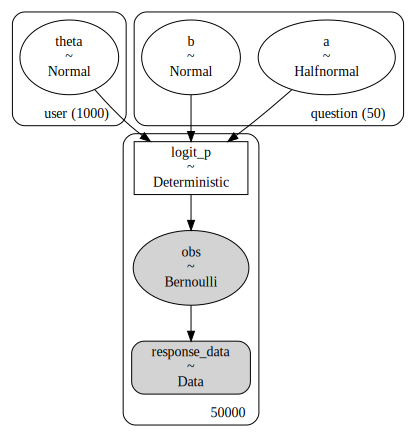

In [9]:
# 配列の項目定義(ユーザ軸と問題軸の2軸)
coords = {'user': users, 'question': questions}

model1 = pm.Model(coords=coords)

with model1:
    # 観測値の配列(1:正答, 0:誤答)
    response_data = pm.Data('response_data', response)

    # 能力値（受験者ごと）
    theta = pm.Normal('theta', mu=0.0, sigma=1.0, dims='user')

    # 識別力（設問ごと）
    a = pm.HalfNormal('a', sigma=1.0, dims='question')
    # 困難度（設問ごと）
    b = pm.Normal('b', mu=0.0, sigma=1.0, dims='question')

    # logit_pの計算(2PLM)
    logit_p = pm.Deterministic('logit_p', a[question_idx] * (theta[user_idx] - b[question_idx]))

    # ベルヌーイ分布の定義(1:正答, 0:誤答)
    obs = pm.Bernoulli('obs', logit_p=logit_p, observed=response_data)

g = pm.model_to_graphviz(model1)
display(g)

サンプリングと結果解析

In [10]:
%%time

with model1:
    idata1 = pm.sample(random_seed=42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta, a, b]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 324 seconds.


CPU times: user 43.6 s, sys: 2.43 s, total: 46 s
Wall time: 5min 35s


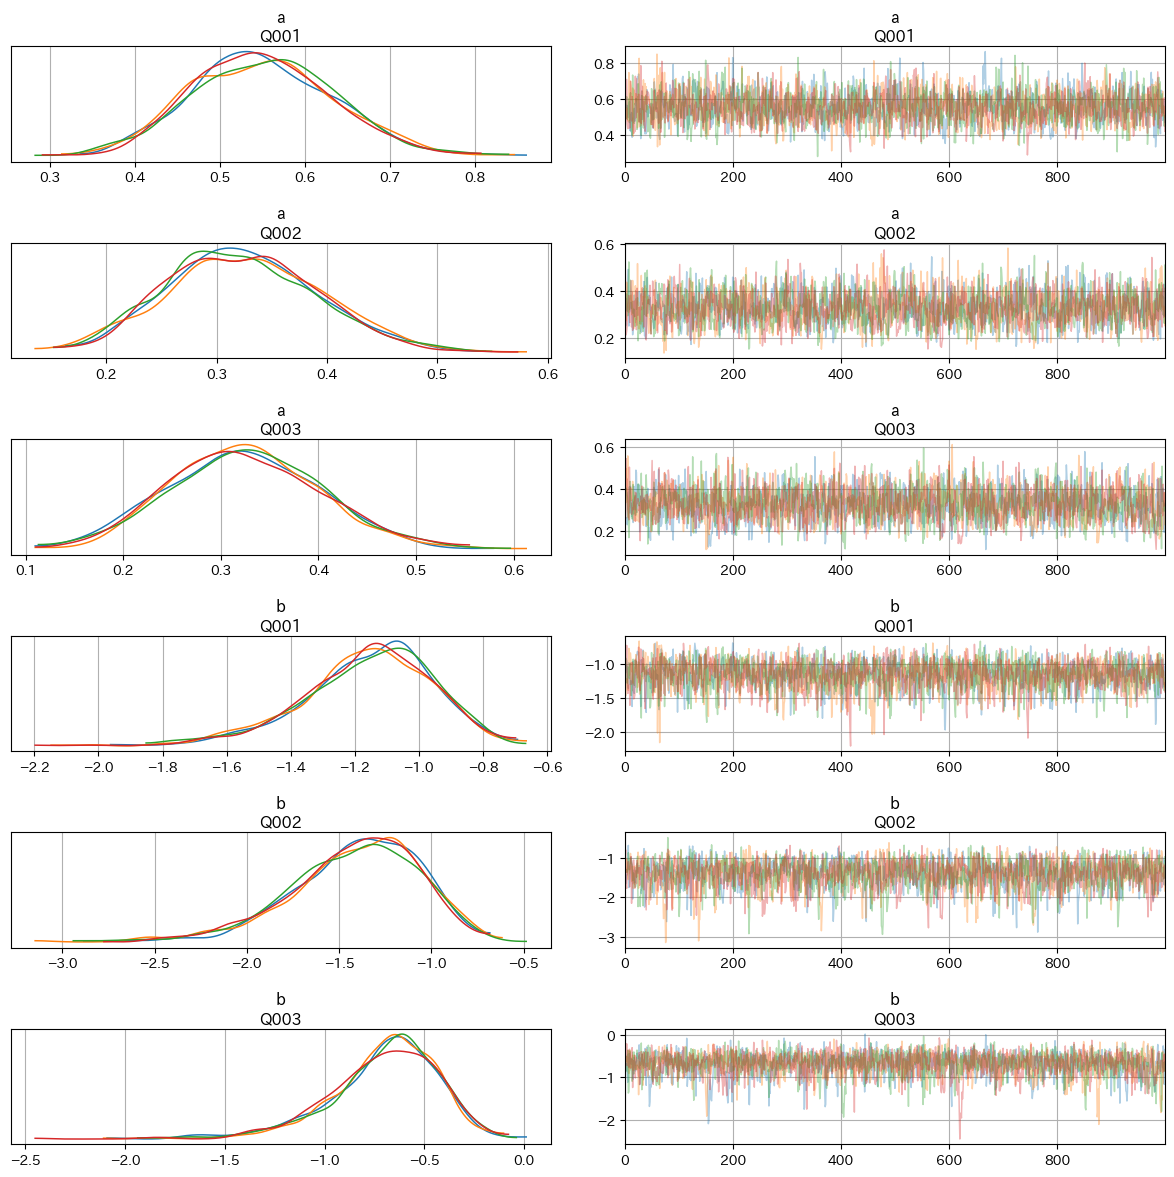

In [11]:
# 設問別
coords_q = {'question': ['Q001', 'Q002', 'Q003']}
az.plot_trace(idata1, var_names=['a','b'], coords=coords_q, compact=False)
plt.tight_layout()

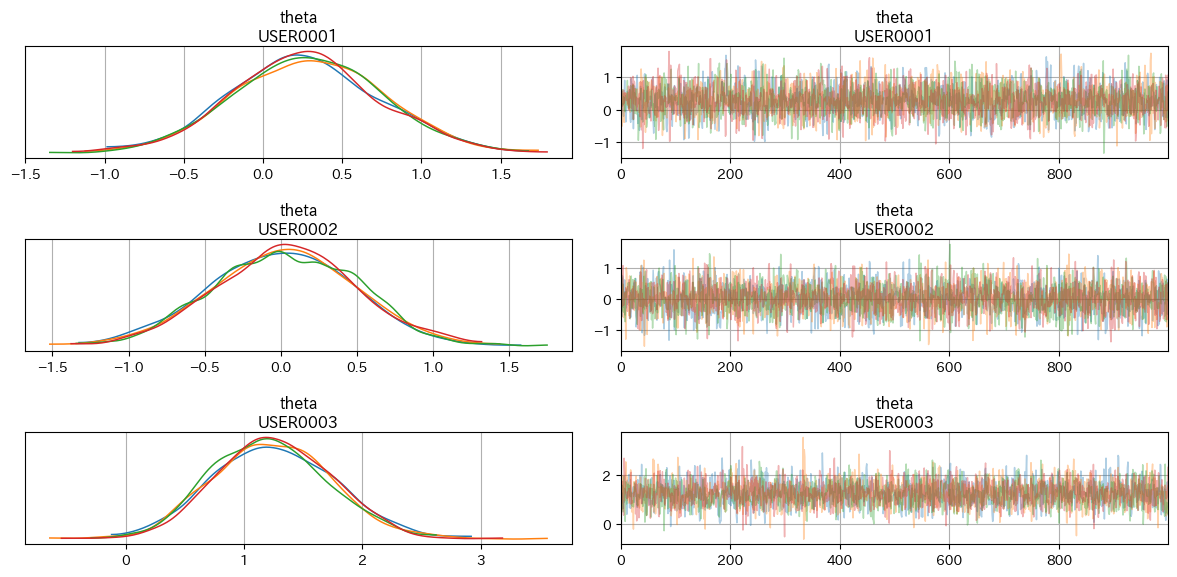

In [12]:
# 受験者別
coords_u = {'user': ['USER0001', 'USER0002', 'USER0003']}
az.plot_trace(idata1, var_names=['theta'], coords=coords_u, compact=False)
plt.tight_layout()

詳細分析

In [13]:
# 問題ごとの統計分析
summary_a1 = az.summary(idata1, var_names=['a'])
summary_b1 = az.summary(idata1, var_names=['b'])
display(summary_a1.head())
display(summary_b1.head())

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a[Q001],0.551,0.084,0.405,0.713,0.002,0.001,2260.000,2269.000,1.000
a[Q002],0.324,0.069,0.203,0.458,0.002,0.001,1921.000,2205.000,1.000
a[Q003],0.325,0.077,0.182,0.470,0.002,0.001,1703.000,1672.000,1.000
a[Q004],0.686,0.097,0.496,0.861,0.002,0.001,1716.000,1799.000,1.000
a[Q005],0.755,0.102,0.574,0.951,0.002,0.002,2133.000,2308.000,1.000


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
b[Q001],-1.159,0.205,-1.554,-0.792,0.004,0.004,2271.000,2366.000,1.000
b[Q002],-1.416,0.355,-2.085,-0.820,0.008,0.008,2064.000,1796.000,1.000
b[Q003],-0.702,0.274,-1.214,-0.230,0.007,0.008,1799.000,1532.000,1.000
b[Q004],-1.811,0.253,-2.272,-1.339,0.007,0.005,1599.000,1749.000,1.000
b[Q005],-2.334,0.291,-2.876,-1.808,0.007,0.005,2052.000,2130.000,1.000


In [14]:
# 受験者ごとの統計分析
summary_theta1 = az.summary(idata1, var_names=['theta'])
display(summary_theta1)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta[USER0001],0.277,0.466,-0.608,1.137,0.007,0.007,3948.000,2513.000,1.000
theta[USER0002],0.022,0.469,-0.955,0.820,0.008,0.008,3760.000,2942.000,1.000
theta[USER0003],1.241,0.502,0.366,2.216,0.008,0.008,3622.000,2857.000,1.000
theta[USER0004],-0.771,0.448,-1.555,0.137,0.007,0.007,4171.000,3042.000,1.000
theta[USER0005],-0.546,0.457,-1.420,0.308,0.007,0.008,4398.000,2970.000,1.000
...,...,...,...,...,...,...,...,...,...
theta[USER0996],0.452,0.469,-0.434,1.332,0.007,0.007,4468.000,2639.000,1.000
theta[USER0997],0.176,0.460,-0.660,1.052,0.007,0.009,4235.000,2627.000,1.000
theta[USER0998],0.626,0.486,-0.290,1.518,0.008,0.008,4233.000,2749.000,1.000
theta[USER0999],0.261,0.468,-0.594,1.138,0.007,0.007,3980.000,3013.000,1.000


In [20]:
summary_theta1.sort_values(by='mean', ascending=False)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta[USER0685],2.363,0.578,1.338,3.518,0.010,0.010,3384.000,2481.000,1.000
theta[USER0559],2.265,0.579,1.180,3.319,0.010,0.010,3699.000,2653.000,1.000
theta[USER0202],2.227,0.578,1.124,3.261,0.009,0.009,4654.000,2545.000,1.000
theta[USER0872],2.225,0.570,1.205,3.334,0.009,0.010,3866.000,2871.000,1.000
theta[USER0688],2.113,0.563,1.030,3.169,0.009,0.010,4273.000,2629.000,1.000
...,...,...,...,...,...,...,...,...,...
theta[USER0957],-2.014,0.480,-2.902,-1.120,0.007,0.008,4220.000,3239.000,1.000
theta[USER0973],-2.103,0.480,-3.042,-1.249,0.008,0.008,3322.000,2583.000,1.000
theta[USER0675],-2.128,0.483,-3.028,-1.250,0.008,0.009,3730.000,2799.000,1.000
theta[USER0910],-2.204,0.461,-3.092,-1.372,0.007,0.007,4965.000,3297.000,1.000


偏差値と能力値の関係

In [21]:
# 受験者ごとの正答率*100を計算し，「素点」とする
df_sum1 = pd.DataFrame((df.mean(axis=1)*100), columns=['素点'])

# 素点を別変数にコピー
X = df_sum1.copy()

# 素点を偏差値のスケールに補正
X_mean, X_std = X.mean(), X.std()
X = (X - X_mean) / X_std * 10 + 50
df_sum1['偏差値'] = X

# 受験者ごとの能力値の平均を抽出
x1 = summary_theta1['mean']

# 能力値を偏差値と同じスケールに補正
x1_mean, x1_std = x1.mean(), x1.std()
x1 = (x1 - x1_mean) / x1_std * 10 + 50
df_sum1['能力値'] = x1.values

display(df_sum1.head(10))

,素点,偏差値,能力値
USER0001,64.000,53.307,52.813
USER0002,58.000,48.449,49.741
USER0003,78.000,64.642,64.427
USER0004,48.000,40.352,40.187
USER0005,50.000,41.971,42.898
USER0006,62.000,51.687,49.126
USER0007,52.000,43.591,41.705
USER0008,54.000,45.210,44.970
USER0009,60.000,50.068,49.174
USER0010,62.000,51.687,49.174


偏差値と能力値の散布図を表示

Text(0, 0.5, '能力値')

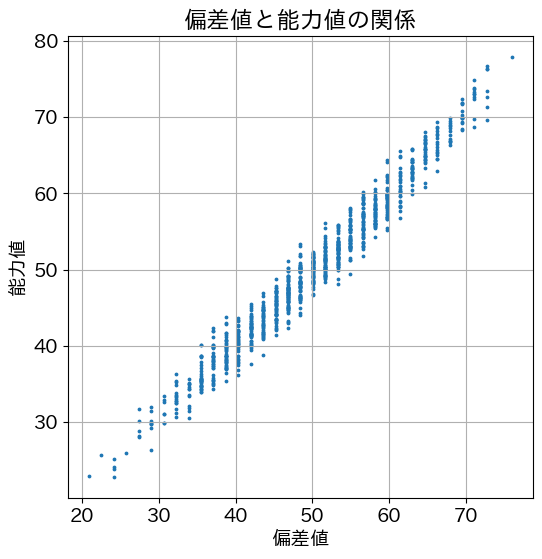

In [22]:
plt.scatter(df_sum1['偏差値'], df_sum1['能力値'], s=3)
plt.title('偏差値と能力値の関係')
plt.xlabel('偏差値')
plt.ylabel('能力値')

同じ偏差値の受験者間の能力値の違いを分析

In [23]:
# 1. 素点62(偏差値51.69)の受験者
df_62_1 = df_sum1.query('素点==62')
print(f'素点62の受験者数: {len(df_62_1)}')

# 2. 一番能力値の低い受験者を抽出
argmin1 = df_62_1['能力値'].values.argmin()
print(f'素点62で一番能力値の低い受験者', df_62_1.iloc[argmin1])

# 3. 一番能力値の高い受験者を抽出
argmax1 = df_62_1['能力値'].values.argmax()
print(f'素点62で一番能力値の高い受験者', df_62_1.iloc[argmax1])

素点62の受験者数: 59
素点62で一番能力値の低い受験者 素点    62.000
偏差値   51.687
能力値   48.440
Name: USER0463, dtype: float64
素点62で一番能力値の高い受験者 素点    62.000
偏差値   51.687
能力値   56.078
Name: USER0064, dtype: float64


In [27]:
# 能力値の異なる2受験者の回答状況を確認

w1 = df.loc[['USER0463', 'USER0064']]
display(w1)

w2 = w1.sum(axis=1)
print(f'w1のshape: {w1.shape}\n正解数: \n{w2}\n')

# 問題別の平均難易度
b_mean_1 = az.summary(idata1, var_names=['b'])['mean'].values.reshape(1,-1)
print(b_mean_1)
print(f'b_meanのshape: {b_mean_1.shape}\n')

# 2人の受験者が説いた問題の平均困難度
w3 = (w1 * b_mean_1).sum(axis=1)/w2.iloc[0]
print(w3)

,Q001,Q002,Q003,Q004,Q005,Q006,Q007,Q008,Q009,Q010,Q011,Q012,Q013,Q014,Q015,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023,Q024,Q025,Q026,Q027,Q028,Q029,Q030,Q031,Q032,Q033,Q034,Q035,Q036,Q037,Q038,Q039,Q040,Q041,Q042,Q043,Q044,Q045,Q046,Q047,Q048,Q049,Q050
USER0463,0,0,1,1,1,1,1,1,0,0,1,0,1,0,0,0,1,1,1,0,1,1,0,0,0,1,1,1,1,1,1,1,1,1,1,0,0,0,1,0,0,1,1,1,1,1,0,0,1,1
USER0064,1,0,1,1,1,0,1,0,0,0,0,1,1,0,1,1,1,1,1,0,0,1,1,0,1,0,1,1,0,1,0,0,1,1,1,0,1,1,1,0,0,1,1,0,1,1,0,1,1,1


w1のshape: (2, 50)
正解数: 
USER0463    31
USER0064    31
dtype: int64

[[-1.159 -1.416 -0.702 -1.811 -2.334 -1.397 -2.093 -1.843  1.255  1.287
  -0.577 -1.946 -0.680  0.289 -0.086  0.332  0.075 -2.359 -1.749 -1.044
  -1.558 -1.838  1.349 -1.487  1.288  1.072 -1.690 -0.286 -1.930 -2.193
  -0.177  0.013 -0.911 -0.646 -1.263  0.264 -1.556 -1.392 -2.073  0.597
  -0.066 -1.295 -2.845 -1.383  0.613  0.455  0.532 -1.750 -2.008 -1.846]]
b_meanのshape: (1, 50)

USER0463   -1.202
USER0064   -1.110
dtype: float64


サンプル値ごとの能力値の分布

In [28]:
# USER0463とUSER0064の能力値のサンプルデータを抽出
w1 = idata1['posterior'].data_vars['theta'].loc[:,:,['USER0463', 'USER0064']].values

w1

array([[[-0.634,  0.922],
        [ 0.519,  0.578],
        [-0.275,  0.542],
        ...,
        [-0.441,  0.441],
        [ 0.106,  0.603],
        [ 0.007,  0.554]],

       [[-0.869,  1.127],
        [ 0.580,  0.223],
        [-0.537,  0.615],
        ...,
        [ 0.228, -0.390],
        [-0.293,  0.397],
        [ 0.049,  0.804]],

       [[-0.645,  0.140],
        [-0.846,  0.321],
        [ 0.394,  0.602],
        ...,
        [-1.005,  0.770],
        [ 0.692,  0.704],
        [-0.587,  0.593]],

       [[-0.239,  0.320],
        [ 0.102,  0.704],
        [-0.174,  0.914],
        ...,
        [-0.113, -0.295],
        [ 0.164,  0.995],
        [-0.289,  0.587]]], shape=(4, 1000, 2))

In [31]:
w2 = w1.transpose()
w2 # (2[受験者数], 1000[サンプリング値], 4[系列])

array([[[-0.634, -0.869, -0.645, -0.239],
        [ 0.519,  0.580, -0.846,  0.102],
        [-0.275, -0.537,  0.394, -0.174],
        ...,
        [-0.441,  0.228, -1.005, -0.113],
        [ 0.106, -0.293,  0.692,  0.164],
        [ 0.007,  0.049, -0.587, -0.289]],

       [[ 0.922,  1.127,  0.140,  0.320],
        [ 0.578,  0.223,  0.321,  0.704],
        [ 0.542,  0.615,  0.602,  0.914],
        ...,
        [ 0.441, -0.390,  0.770, -0.295],
        [ 0.603,  0.397,  0.704,  0.995],
        [ 0.554,  0.804,  0.593,  0.587]]], shape=(2, 1000, 4))

In [32]:
w2 = w2.reshape(2,-1)
w2

array([[-0.634, -0.869, -0.645, ...,  0.049, -0.587, -0.289],
       [ 0.922,  1.127,  0.140, ...,  0.804,  0.593,  0.587]],
      shape=(2, 4000))

In [33]:
# 能力値のスケール変更
w3 = (w2 - x1_mean) / x1_std * 10 + 50

Text(0.5, 1.0, 'サンプル値ごとの能力値の分布')

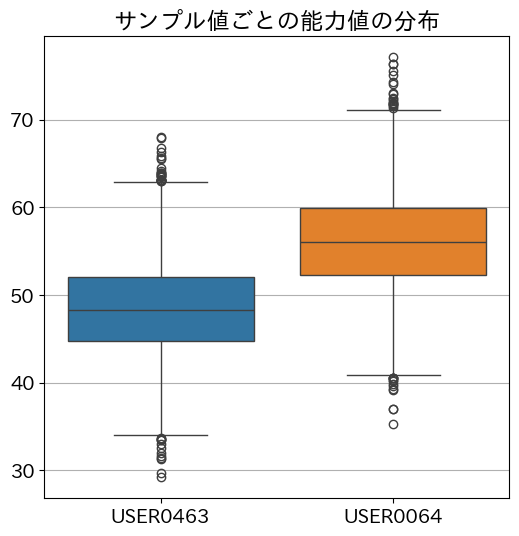

In [34]:
# 受験者を列名とするデータフレームに変換
df_w3 = pd.DataFrame(w3.T, columns=['USER0463', 'USER0064'])

sns.boxplot(df_w3)
plt.title('サンプル値ごとの能力値の分布')

## 変分推論法
+ MCMC法だとサンプリングが多いと時間がかかって，実時間成約のある実務で困る
+ MC法による平均化による期待値の取得(大数の法則)の利用の代替手法

### PyMCでの実行方法
1. fit関数の呼び出し
2. 収束確認
3. サンプリング

In [35]:
# 配列の項目定義(ユーザ軸と問題軸の2軸)
coords = {'user': users, 'question': questions}

model2 = pm.Model(coords=coords)

with model2:
    # 観測値の配列(1:正答, 0:誤答)
    response_data = pm.Data('response_data', response)

    # 能力値（受験者ごと）
    theta = pm.Normal('theta', mu=0.0, sigma=1.0, dims='user')

    # 識別力（設問ごと）
    a = pm.HalfNormal('a', sigma=1.0, dims='question')
    # 困難度（設問ごと）
    b = pm.Normal('b', mu=0.0, sigma=1.0, dims='question')

    # logit_pの計算(2PLM)
    logit_p = pm.Deterministic('logit_p', a[question_idx] * (theta[user_idx] - b[question_idx]))

    # ベルヌーイ分布の定義(1:正答, 0:誤答)
    obs = pm.Bernoulli('obs', logit_p=logit_p, observed=response_data) 

In [37]:
%%time

with model2:
    mean_field = pm.fit(method=pm.ADVI(), n=20000, obj_optimizer=pm.adam()) # 勾配効果法はADAMを使う

Output()

Finished [100%]: Average Loss = 30,872


CPU times: user 1min 2s, sys: 167 ms, total: 1min 2s
Wall time: 1min 13s


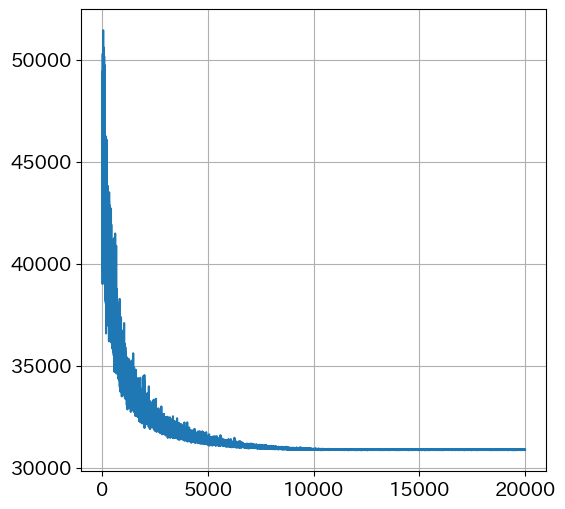

In [38]:
# 収束の確認(NNの損失チェックと同じ)
plt.plot(mean_field.hist)

変分推論法のサンプリング

In [39]:
%%time

idata2 = mean_field.sample(2000) # 系列chain数は1

CPU times: user 415 ms, sys: 242 ms, total: 657 ms
Wall time: 4.09 s


結果分析

In [40]:
# 偏差値と能力値の算出 (能力値同士で比較は無理．自由度が一つ残ってる)

summary_theta2 = az.summary(idata2, var_names=['theta'])

df_sum2 = df_sum1.copy()

# 受験者ごとの能力値の平均を抽出
x2 = summary_theta2['mean'].values

# 能力値を偏差値と同じスケールに補正
x2_mean, x2_std = x2.mean(), x2.std()
x2 = (x2 - x2_mean) / x2_std * 10 + 50
df_sum2['能力値2'] = x2

display(df_sum2.head(10))

arviz - WARNING - Shape validation failed: input_shape: (1, 2000), minimum_shape: (chains=2, draws=4)


,素点,偏差値,能力値,能力値2
USER0001,64.000,53.307,52.813,53.090
USER0002,58.000,48.449,49.741,49.567
USER0003,78.000,64.642,64.427,64.581
USER0004,48.000,40.352,40.187,40.309
USER0005,50.000,41.971,42.898,42.830
USER0006,62.000,51.687,49.126,49.029
USER0007,52.000,43.591,41.705,41.790
USER0008,54.000,45.210,44.970,45.254
USER0009,60.000,50.068,49.174,48.599
USER0010,62.000,51.687,49.174,49.316


変分推論法で求めた能力値をサンプル値ごとの分布で表示

Text(0.5, 1.0, 'サンプル値ごとの能力値の分布(変分推論法)')

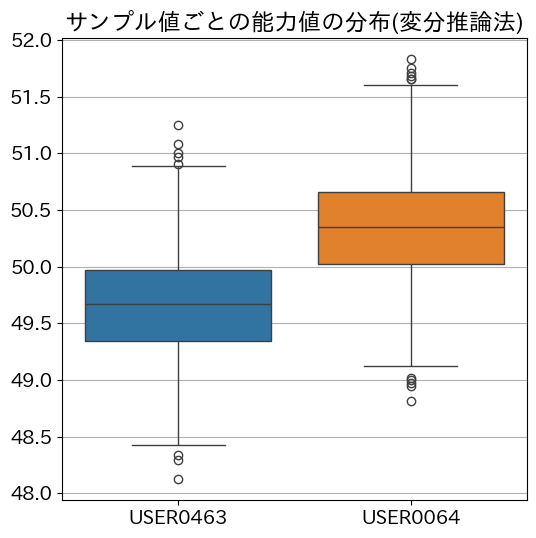

In [41]:
# USER0463とUSER0064の能力値のサンプルデータを抽出
w1 = idata2['posterior'].data_vars['theta'].loc[:,:,['USER0463', 'USER0064']].values

w2 = w1.transpose().reshape(2, -1)

# 能力値を偏差値にスケール変更
w3 = (w2 - w2.mean()) / x2.std() * 10 + 50

df_w3 = pd.DataFrame(w3.T, columns=['USER0463', 'USER0064'])

sns.boxplot(df_w3)
plt.title('サンプル値ごとの能力値の分布(変分推論法)')